In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset=fetch_ucirepo(id=45)

Data set link : https://archive.ics.uci.edu/dataset/45/heart+disease

In [3]:
df=dataset.data.original

In [4]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


In [5]:
df.to_csv('Datasets/heart_disease.csv',index=False)

In [6]:
df['sex']=df['sex'].replace({1:'male',0:'female'})
df['num']=df['num'].apply(lambda x: 1 if x>0 else 0)

Value of num:
0-->Healthy
1-->Disease

In [7]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,male,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,male,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,male,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,male,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,female,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,male,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,male,4,144,193,1,0,141,0,3.4,2,2.0,7.0,1
300,57,male,4,130,131,0,0,115,1,1.2,2,1.0,7.0,1
301,57,female,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


In [8]:
df.shape

(303, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(10), object(1)
memory usage: 33.3+ KB


In [10]:
df.describe()

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [11]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
num_col=['age','trestbps','chol','thalach','oldpeak','ca']
tar_col=['num']
cat_col=['sex','cp','fbs','restecg','exang','slope','thal']

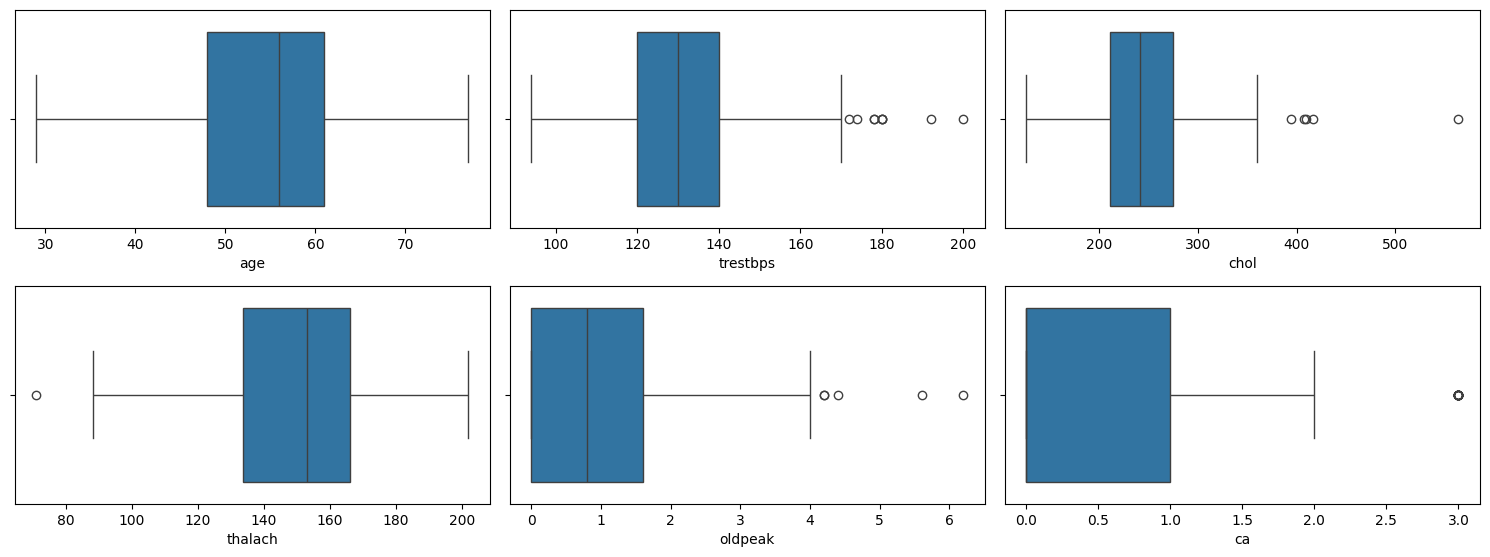

In [14]:
plt.figure(figsize=(15,8))
for i,j in enumerate(num_col,1):
    plt.subplot(3,3,i)
    sns.boxplot(data=df,x=df[j])
plt.tight_layout()
plt.show()

There are very less outliers,and in medical dataset outliers might be usefull,so we don't need to remove it.

In [15]:
df.corr(numeric_only=True)

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
age,1.000000,0.104139,0.284946,0.208950,0.118530,0.148868,-0.393806,0.091661,0.203805,0.161770,0.362605,0.127389,0.223120
cp,0.104139,1.000000,-0.036077,0.072319,-0.039975,0.067505,-0.334422,0.384060,0.202277,0.152050,0.233214,0.265246,0.414446
trestbps,0.284946,-0.036077,1.000000,0.130120,0.175340,0.146560,-0.045351,0.064762,0.189171,0.117382,0.098773,0.133554,0.150825
chol,0.208950,0.072319,0.130120,1.000000,0.009841,0.171043,-0.003432,0.061310,0.046564,-0.004062,0.119000,0.014214,0.085164
fbs,0.118530,-0.039975,0.175340,0.009841,1.000000,0.069564,-0.007854,0.025665,0.005747,0.059894,0.145478,0.071358,0.025264
restecg,0.148868,0.067505,0.146560,0.171043,0.069564,1.000000,-0.083389,0.084867,0.114133,0.133946,0.128343,0.024531,0.169202
thalach,-0.393806,-0.334422,-0.045351,-0.003432,-0.007854,-0.083389,1.000000,-0.378103,-0.343085,-0.385601,-0.264246,-0.279631,-0.417167
exang,0.091661,0.384060,0.064762,0.061310,0.025665,0.084867,-0.378103,1.000000,0.288223,0.257748,0.145570,0.329680,0.431894
oldpeak,0.203805,0.202277,0.189171,0.046564,0.005747,0.114133,-0.343085,0.288223,1.000000,0.577537,0.295832,0.341004,0.424510
slope,0.161770,0.152050,0.117382,-0.004062,0.059894,0.133946,-0.385601,0.257748,0.577537,1.000000,0.110119,0.287232,0.339213


<Axes: >

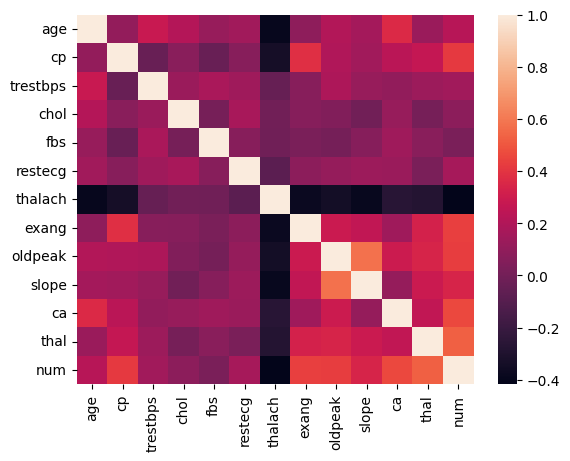

In [16]:
sns.heatmap(df.corr(numeric_only=True))

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns='num',axis=1),
                                               df['num'],
                                               test_size=0.2,
                                               random_state=42,
                                              stratify=df['num'])

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.impute import SimpleImputer

In [20]:
num_pipe=Pipeline([
    ('si',SimpleImputer(strategy='median')),
    ('ss',StandardScaler())
])
ctf=ColumnTransformer([
    ('num',num_pipe,num_col),
    ('ohe',OneHotEncoder(drop='first',handle_unknown='ignore'),cat_col)
],remainder='passthrough')

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

In [22]:
models={
    'LogisticRegression':LogisticRegression(max_iter=5000,class_weight='balanced',random_state=42,solver='saga'),
    'DecisionTree':DecisionTreeClassifier(random_state=42),
    'RandomForest':RandomForestClassifier(n_estimators=50,n_jobs=-1,random_state=42),
    'XGBoost':XGBClassifier(random_state=42),
    'SVM':SVC(kernel='rbf',C=1.0,gamma='scale',probability=True,random_state=42)
}

In [23]:
for name,model in models.items():
    pipe=Pipeline([
        ('preprocessing',ctf),
        ('model',model)
    ])
    pipe.fit(x_train,y_train)
    y_pred=pipe.predict(x_test)
    acc=accuracy_score(y_pred,y_test)
    cv=cross_val_score(pipe,df.drop(columns=['num']),df['num'],cv=5,scoring='accuracy')
    print(f'{name}')
    print(f'accuracy:{acc:.4f}')
    print(f'CV average:{cv.mean():.4f}')
    print(classification_report(y_test,y_pred))

LogisticRegression
accuracy:0.8525
CV average:0.8281
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61

DecisionTree
accuracy:0.8197
CV average:0.7456
              precision    recall  f1-score   support

           0       0.87      0.79      0.83        33
           1       0.77      0.86      0.81        28

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61

RandomForest
accuracy:0.9016
CV average:0.8181
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                       

SVM is giving best result,so we will use SVM for this project

In [24]:
pipe_svm=Pipeline([
    ('preprocessing',ctf),
    ('svm',SVC(kernel='rbf',C=1.0,gamma='scale',probability=True,random_state=42))
])

In [25]:
pipe_svm.fit(x_train,y_train)

,steps,"[('preprocessing', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ohe', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
y_pred=pipe_svm.predict(x_test)

In [27]:
accuracy_score(y_pred,y_test)

0.9344262295081968

In [28]:
import pickle

In [29]:
pickle.dump(pipe_svm,open('models/heart_disease.pkl','wb'))